# EDA temporal por variavel - Rio de Janeiro

## Objetivo
Analisar o comportamento temporal de cada variavel de qualidade do ar (poluentes e atmosfericas), cobrindo:
- sazonalidade por mes, dia da semana e ano,
- tendencia de longo prazo com decomposicao temporal,
- dias/picos criticos e frequencia de eventos extremos.


## 1. Importacoes e configuracoes


In [23]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, List
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

URL_DADOS = (
    "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/"
    "refs/heads/Refactoring-And-Documentation/"
    "Data/IntermediaryData/MonitorAr/DailyQualiarRj/"
    "serie_diaria_qualidade_ar_rio_de_janeiro.csv"
)

COLUNA_DATA = "data"
PERIODO_SAZONAL = 365
JANELA_TENDENCIA_FALLBACK = 90
TOP_N_PICOS = 10

VARIAVEIS_ORDEM: List[str] = [
    "pm10",
    "pm2_5",
    "o3",
    "no2",
    "so2",
    "co",
    "no",
    "nox",
    "temp",
    "ur",
    "chuva",
]

POLUENTES = {"pm10", "pm2_5", "o3", "no2", "so2", "co", "pts", "no", "nox"}

MESES_PT = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
DIAS_SEMANA_PT = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]

## 2. Carregamento e preparacao da base


In [24]:
df_rj = pd.read_csv(URL_DADOS, parse_dates=[COLUNA_DATA])
df_rj[COLUNA_DATA] = pd.to_datetime(df_rj[COLUNA_DATA], errors="coerce").dt.normalize()
df_rj = df_rj.dropna(subset=[COLUNA_DATA]).sort_values(COLUNA_DATA).reset_index(drop=True)

colunas_numericas = df_rj.select_dtypes(include="number").columns.tolist()
variaveis_disponiveis = [v for v in VARIAVEIS_ORDEM if v in colunas_numericas]

if not variaveis_disponiveis:
    raise RuntimeError("Nenhuma variavel elegivel foi encontrada na base para EDA temporal.")

print(f"Fonte usada: {URL_DADOS}")
print(f"Periodo: {df_rj[COLUNA_DATA].min():%Y-%m-%d} ate {df_rj[COLUNA_DATA].max():%Y-%m-%d}")
print(f"Total de linhas: {len(df_rj):,}")
print(f"Variaveis analisadas: {variaveis_disponiveis}")
display(df_rj.head())


Fonte usada: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/DailyQualiarRj/serie_diaria_qualidade_ar_rio_de_janeiro.csv
Periodo: 2012-01-01 ate 2018-12-31
Total de linhas: 2,557
Variaveis analisadas: ['pm10', 'pm2_5', 'o3', 'no2', 'so2', 'co', 'no', 'nox', 'temp', 'ur', 'chuva']


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva
0,2012-01-01,5.762,22.376,2.667,14.508,28.102,92.521,25.556,22.905,0.397,22.838,228.2
1,2012-01-02,25.347,29.317,2.290,8.158,54.670,95.074,22.264,13.924,0.311,14.965,371.0
2,2012-01-03,23.367,28.593,3.704,9.875,51.883,73.642,25.091,15.997,0.243,26.374,0.2
3,2012-01-04,28.645,36.209,3.177,14.823,64.833,72.631,26.083,23.245,0.267,35.924,0.4
4,2012-01-05,17.859,31.785,3.113,11.958,49.605,74.860,26.661,36.343,0.250,31.761,0.0


## 3. Funcoes auxiliares para EDA temporal


In [25]:
def preparar_serie_para_decomposicao(df: pd.DataFrame, variavel: str) -> pd.Series:
    # Reindexa para frequencia diaria completa e interpola para remover lacunas.
    base = df[[COLUNA_DATA, variavel]].dropna(subset=[COLUNA_DATA]).copy()
    base = base.set_index(COLUNA_DATA).sort_index()

    idx = pd.date_range(base.index.min(), base.index.max(), freq="D")
    serie = base[variavel].reindex(idx)

    # Preenche lacunas para viabilizar decomposicao.
    serie = serie.interpolate(method="time").ffill().bfill()
    return serie


def plot_sazonalidade(df: pd.DataFrame, variavel: str) -> Dict[str, pd.DataFrame]:
    base = df[[COLUNA_DATA, variavel]].dropna(subset=[variavel]).copy()
    base["mes"] = base[COLUNA_DATA].dt.month
    base["dia_semana"] = base[COLUNA_DATA].dt.dayofweek
    base["ano"] = base[COLUNA_DATA].dt.year

    saz_mes = base.groupby("mes", as_index=False)[variavel].mean()
    saz_semana = base.groupby("dia_semana", as_index=False)[variavel].mean()
    saz_ano = base.groupby("ano", as_index=False)[variavel].mean()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Sazonalidade mensal.
    x_mes = saz_mes["mes"].astype(int)
    y_mes = saz_mes[variavel]
    axes[0].bar(x_mes, y_mes, color="#2a9d8f")
    axes[0].set_title(f"{variavel} - media por mes")
    axes[0].set_xticks(range(1, 13))
    axes[0].set_xticklabels(MESES_PT, rotation=45)

    # Sazonalidade por dia da semana.
    x_sem = saz_semana["dia_semana"].astype(int)
    y_sem = saz_semana[variavel]
    axes[1].bar(x_sem, y_sem, color="#1d3557")
    axes[1].set_title(f"{variavel} - media por dia da semana")
    axes[1].set_xticks(range(0, 7))
    axes[1].set_xticklabels(DIAS_SEMANA_PT)

    # Evolucao anual.
    axes[2].plot(saz_ano["ano"], saz_ano[variavel], marker="o", color="#e76f51")
    axes[2].set_title(f"{variavel} - media por ano")
    axes[2].set_xlabel("Ano")

    for ax in axes:
        ax.set_ylabel(variavel)

    plt.tight_layout()
    plt.show()

    return {
        "mes": saz_mes,
        "dia_semana": saz_semana,
        "ano": saz_ano,
    }


def plot_tendencia_longo_prazo(df: pd.DataFrame, variavel: str) -> Dict[str, object]:
    serie = preparar_serie_para_decomposicao(df, variavel)

    decomp = seasonal_decompose(serie, model="additive", period=PERIODO_SAZONAL, extrapolate_trend="freq")
    fig = decomp.plot()
    fig.set_size_inches(14, 8)
    plt.tight_layout()
    plt.show()

    tendencia = decomp.trend.dropna()
    origem = "seasonal_decompose"

    # Inclina uma reta na tendencia para indicar direcao geral.
    x = np.arange(len(tendencia), dtype=float)
    y = tendencia.values.astype(float)
    slope = float(np.polyfit(x, y, 1)[0]) if len(tendencia) > 1 else np.nan

    return {
        "origem": origem,
        "tendencia": tendencia,
        "slope": slope,
    }


def analisar_extremos(df: pd.DataFrame, variavel: str) -> Dict[str, object]:
    base = df[[COLUNA_DATA, variavel]].dropna(subset=[variavel]).copy()

    p5 = float(base[variavel].quantile(0.05))
    p95 = float(base[variavel].quantile(0.95))

    mascara_extremo_alto = base[variavel] >= p95
    mascara_extremo_baixo = base[variavel] <= p5

    extremos_altos = base.loc[mascara_extremo_alto].copy()
    extremos_baixos = base.loc[mascara_extremo_baixo].copy()

    freq_alta_pct = (len(extremos_altos) / len(base)) * 100 if len(base) else np.nan
    freq_baixa_pct = (len(extremos_baixos) / len(base)) * 100 if len(base) else np.nan

    picos_criticos = base.sort_values(variavel, ascending=False).head(TOP_N_PICOS)

    resumo = pd.DataFrame(
        [
            {
                "variavel": variavel,
                "p5": p5,
                "p95": p95,
                "qtd_extremos_altos": len(extremos_altos),
                "freq_extremos_altos_pct": freq_alta_pct,
                "qtd_extremos_baixos": len(extremos_baixos),
                "freq_extremos_baixos_pct": freq_baixa_pct,
                "maximo": float(base[variavel].max()),
            }
        ]
    ).round(3)

    return {
        "resumo": resumo,
        "picos_criticos": picos_criticos,
        "extremos_altos": extremos_altos,
        "extremos_baixos": extremos_baixos,
    }


## 4. Setup da analise por variavel


In [26]:
resultados_temporais: Dict[str, Dict[str, object]] = {}


def executar_eda_temporal_variavel(variavel: str) -> None:
    if variavel not in variaveis_disponiveis:
        display(Markdown(f"Variavel `{variavel}` nao encontrada na base atual."))
        return

    grupo = "poluente" if variavel in POLUENTES else "atmosferica"

    display(Markdown("### 1. Sazonalidade por mes, dia da semana e ano"))
    sazonalidade = plot_sazonalidade(df_rj, variavel)

    display(Markdown("### 2. Tendencia de longo prazo (decomposicao temporal)"))
    tendencia = plot_tendencia_longo_prazo(df_rj, variavel)

    display(Markdown("### 3. Dias/picos criticos e frequencia de eventos extremos"))
    extremos = analisar_extremos(df_rj, variavel)
    display(extremos["resumo"])
    display(Markdown(f"Top {TOP_N_PICOS} picos criticos:"))
    display(extremos["picos_criticos"])

    resultados_temporais[variavel] = {
        "grupo": grupo,
        "sazonalidade": sazonalidade,
        "tendencia": tendencia,
        "extremos": extremos,
    }


## 5. EDA temporal por variavel


## 5.1 Variavel `pm10` (poluente)


### 1. Sazonalidade por mes, dia da semana e ano

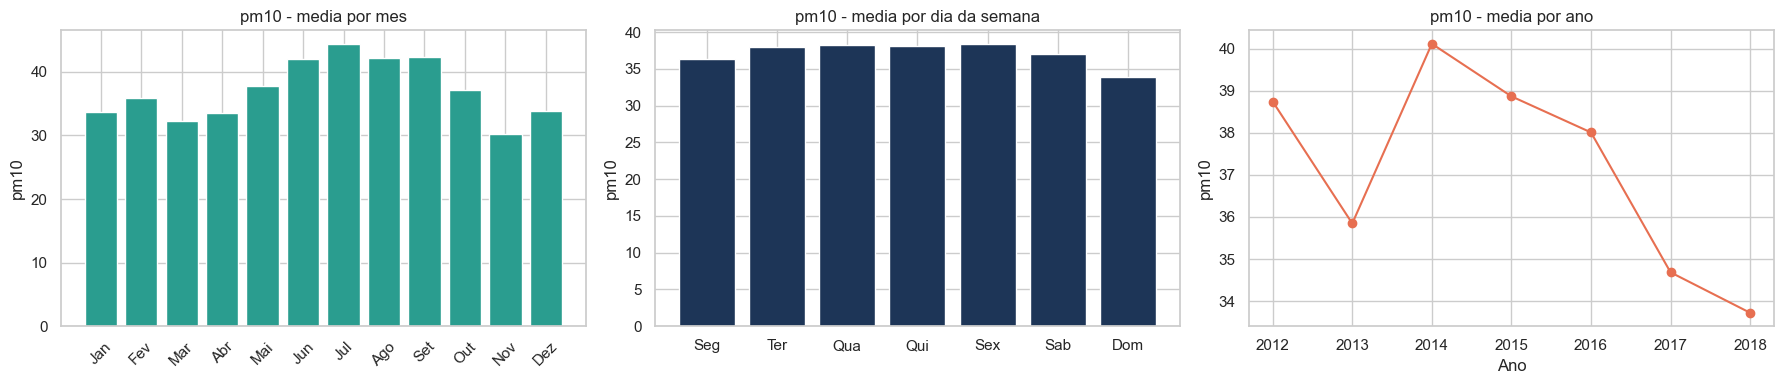

### 2. Tendencia de longo prazo (decomposicao temporal)

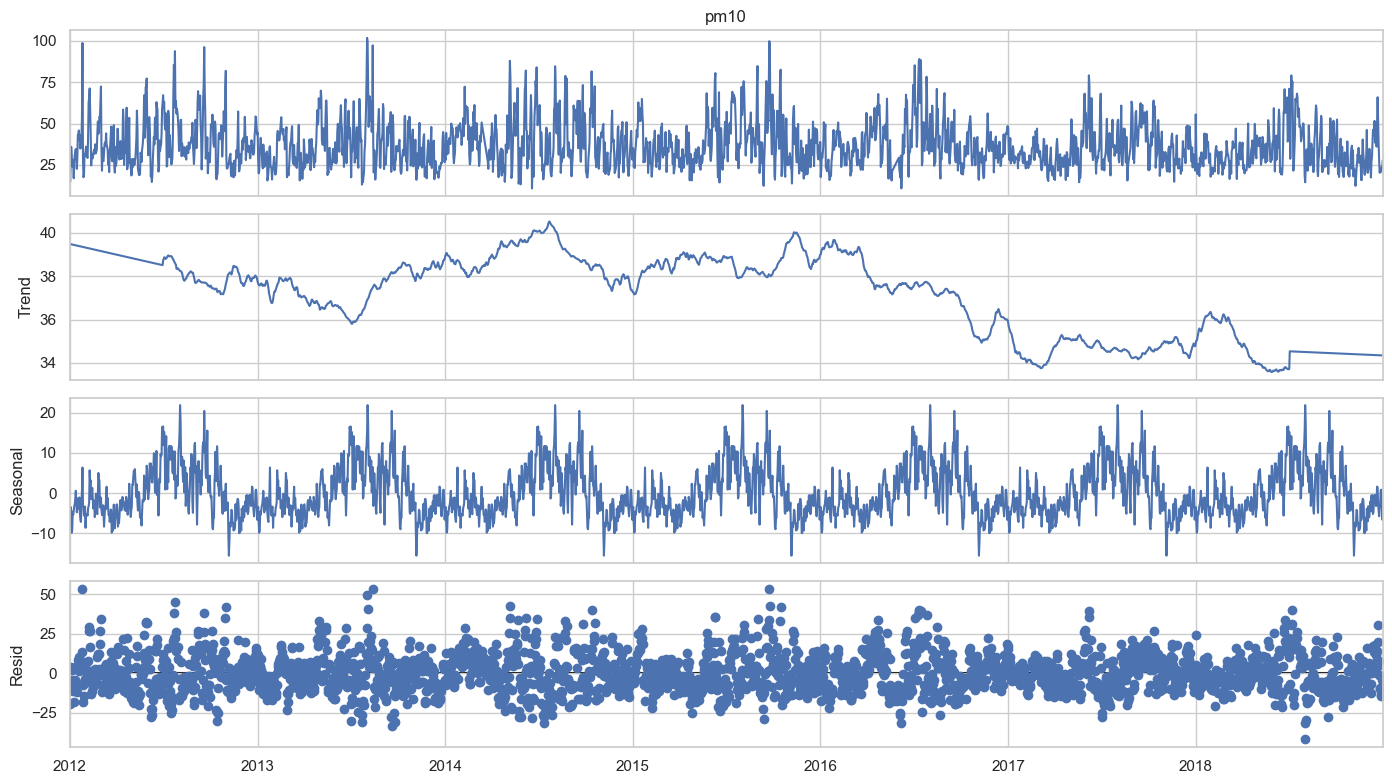

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,pm10,19.171,63.317,127,5.012,127,5.012,101.855


Top 10 picos criticos:

,data,pm10
579,2013-08-02,101.855
1362,2015-09-24,99.862
580,2013-08-03,99.371
25,2012-01-26,98.763
590,2013-08-13,97.354
262,2012-09-19,96.271
1363,2015-09-25,95.788
205,2012-07-24,93.831
1654,2016-07-12,89.054
1653,2016-07-11,88.299


In [27]:
executar_eda_temporal_variavel("pm10")


## 5.2 Variavel `pm2_5` (poluente)


### 1. Sazonalidade por mes, dia da semana e ano

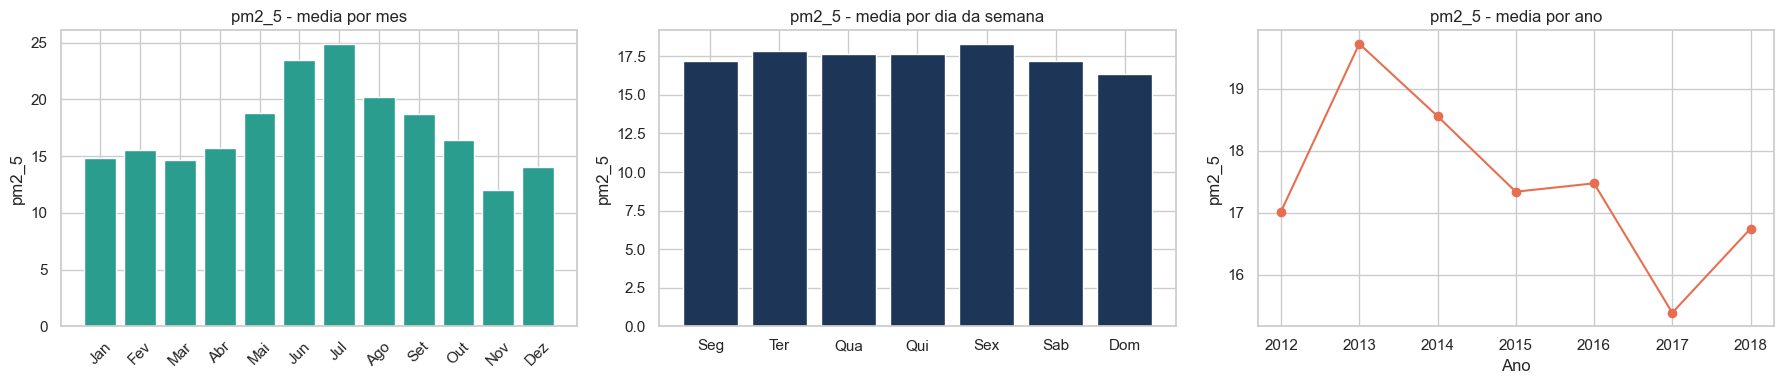

### 2. Tendencia de longo prazo (decomposicao temporal)

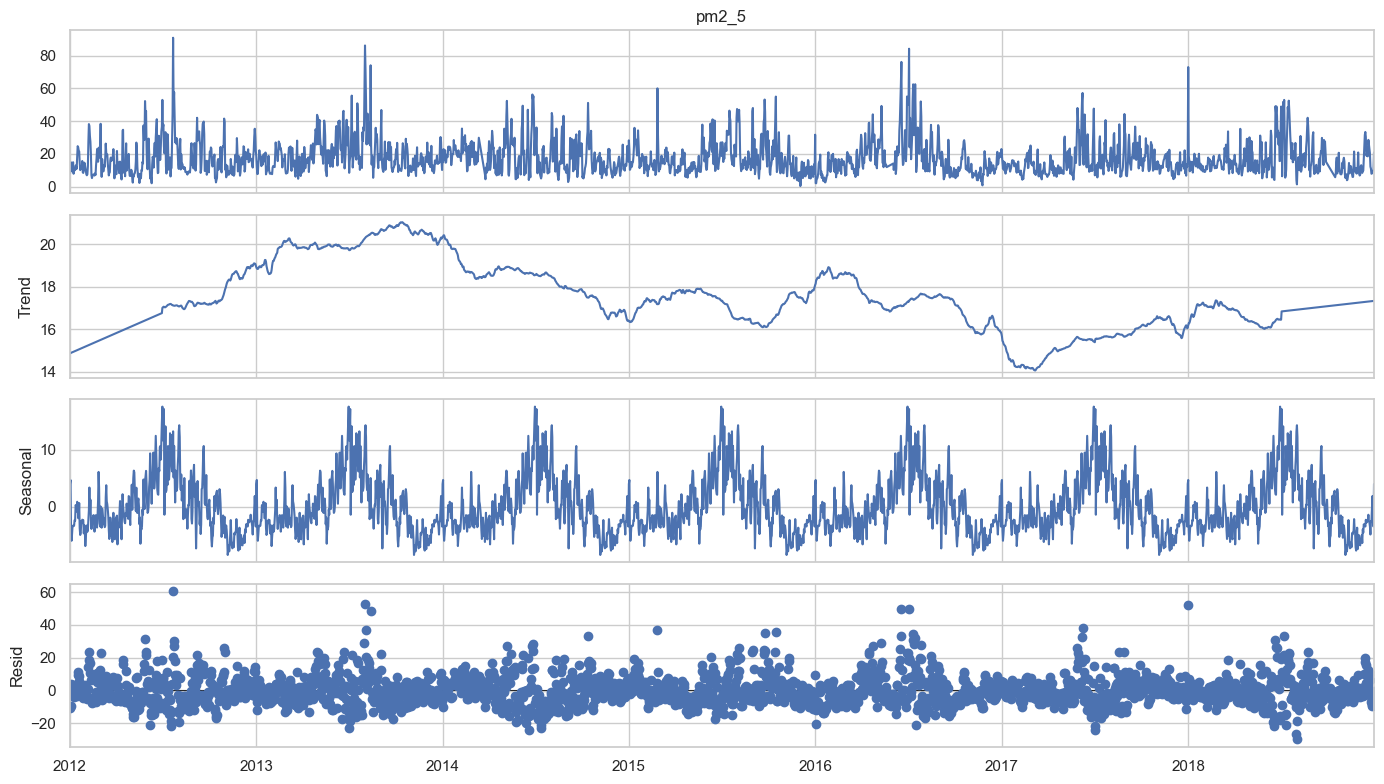

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,pm2_5,6.325,38.005,126,5.008,126,5.008,91.007


Top 10 picos criticos:

,data,pm2_5
203,2012-07-22,91.007
579,2013-08-02,86.281
1645,2016-07-03,84.292
1630,2016-06-18,76.229
590,2013-08-13,74.167
2192,2018-01-01,73.083
580,2013-08-03,71.312
1629,2016-06-17,62.833
1657,2016-07-15,62.583
1653,2016-07-11,62.542


In [28]:
executar_eda_temporal_variavel("pm2_5")


## 5.3 Variavel `o3` (poluente)


### 1. Sazonalidade por mes, dia da semana e ano

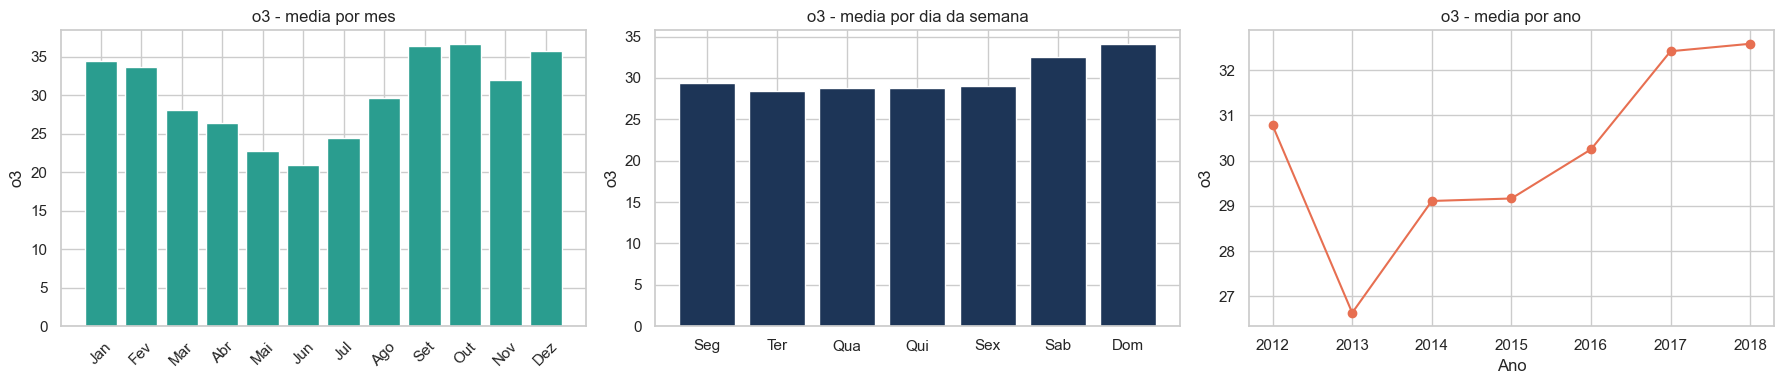

### 2. Tendencia de longo prazo (decomposicao temporal)

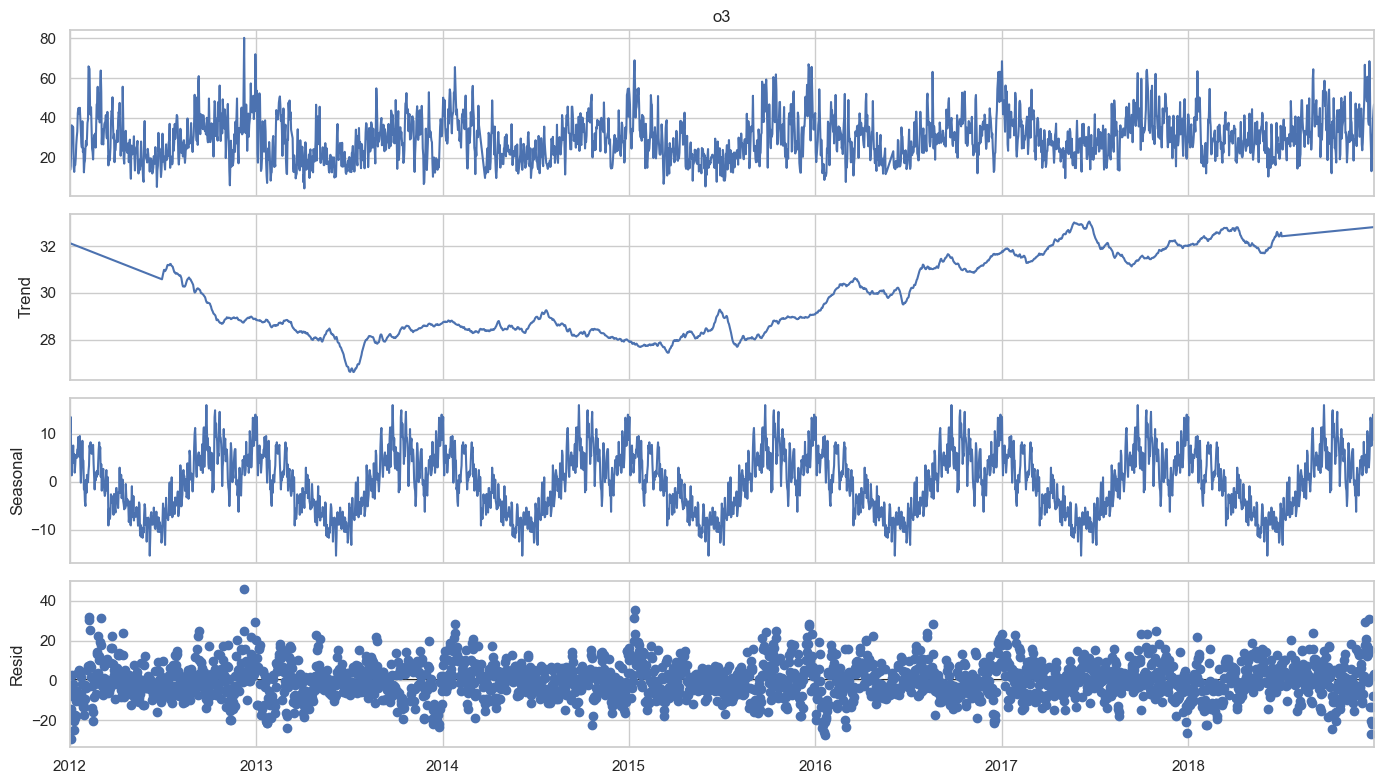

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,o3,14.336,50.386,127,5.012,127,5.012,80.184


Top 10 picos criticos:

,data,o3
342,2012-12-08,80.184
364,2012-12-30,71.981
1107,2015-01-12,68.918
2547,2018-12-22,68.484
1827,2017-01-01,68.464
1448,2015-12-19,66.928
2538,2018-12-13,66.684
37,2012-02-07,65.891
1454,2015-12-25,65.628
755,2014-01-25,65.538


In [29]:
executar_eda_temporal_variavel("o3")


## 5.4 Variavel `no2` (poluente)


### 1. Sazonalidade por mes, dia da semana e ano

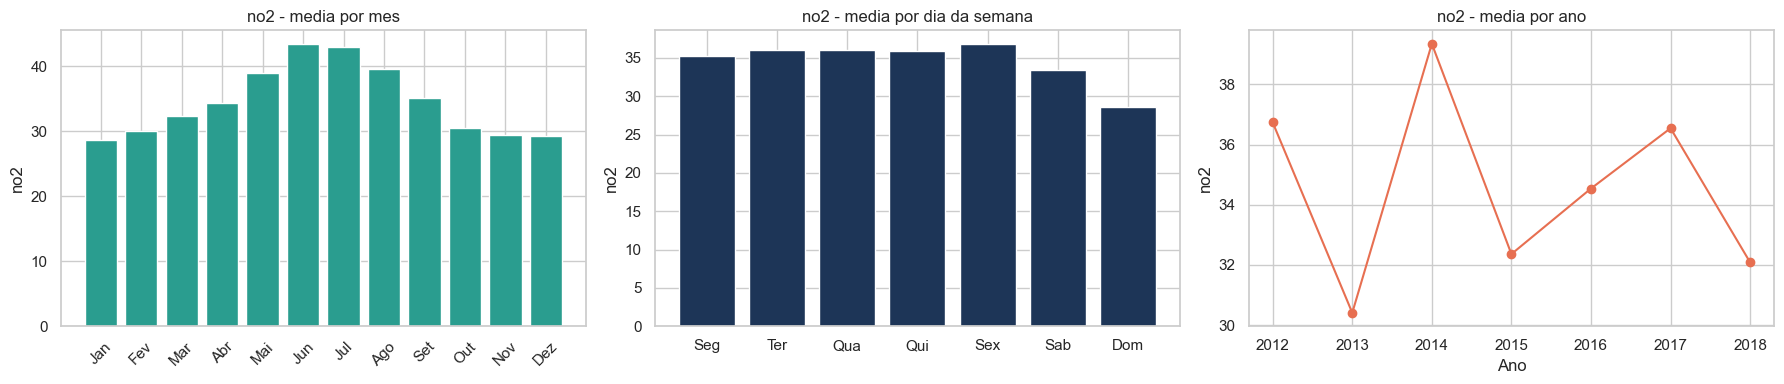

### 2. Tendencia de longo prazo (decomposicao temporal)

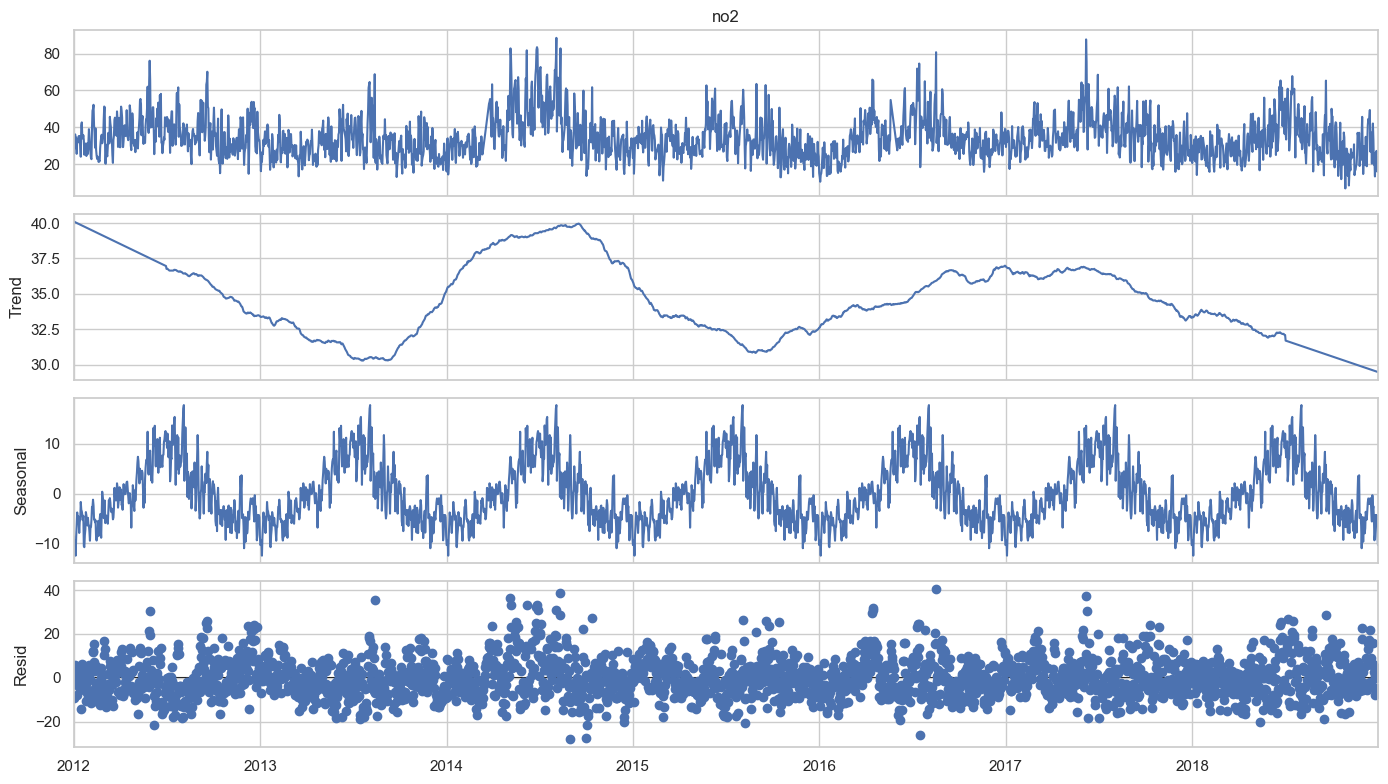

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,no2,19.358,55.344,127,5.012,127,5.012,88.473


Top 10 picos criticos:

,data,no2
946,2014-08-04,88.473
1984,2017-06-07,87.636
908,2014-06-27,83.434
954,2014-08-12,82.794
856,2014-05-06,82.786
909,2014-06-28,82.339
907,2014-06-26,82.025
888,2014-06-07,81.724
1690,2016-08-17,80.699
857,2014-05-07,78.698


In [30]:
executar_eda_temporal_variavel("no2")


## 5.5 Variavel `so2` (poluente)


### 1. Sazonalidade por mes, dia da semana e ano

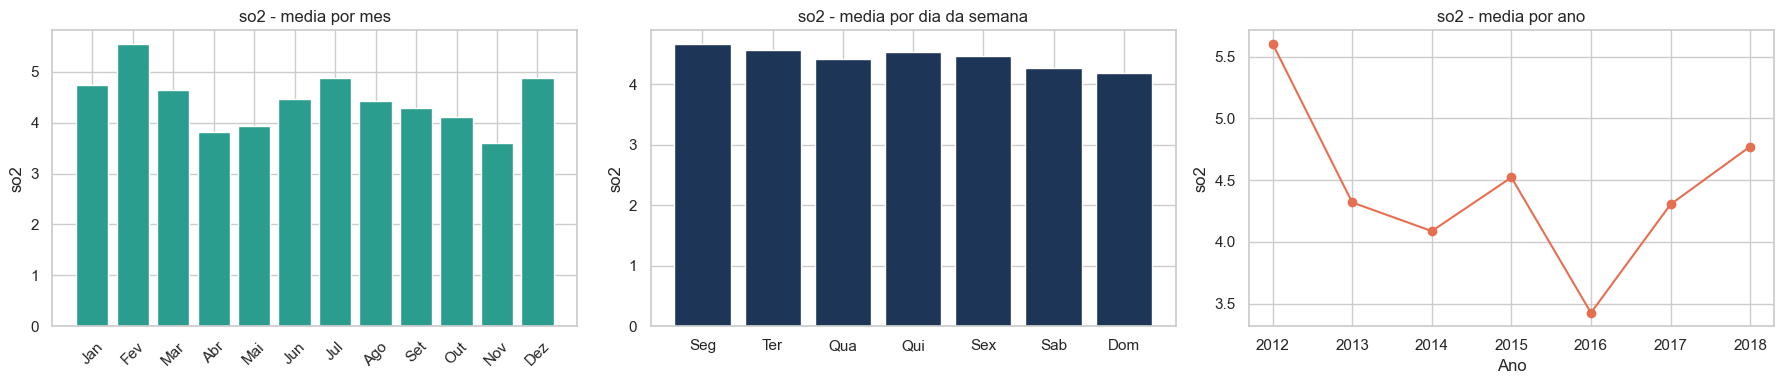

### 2. Tendencia de longo prazo (decomposicao temporal)

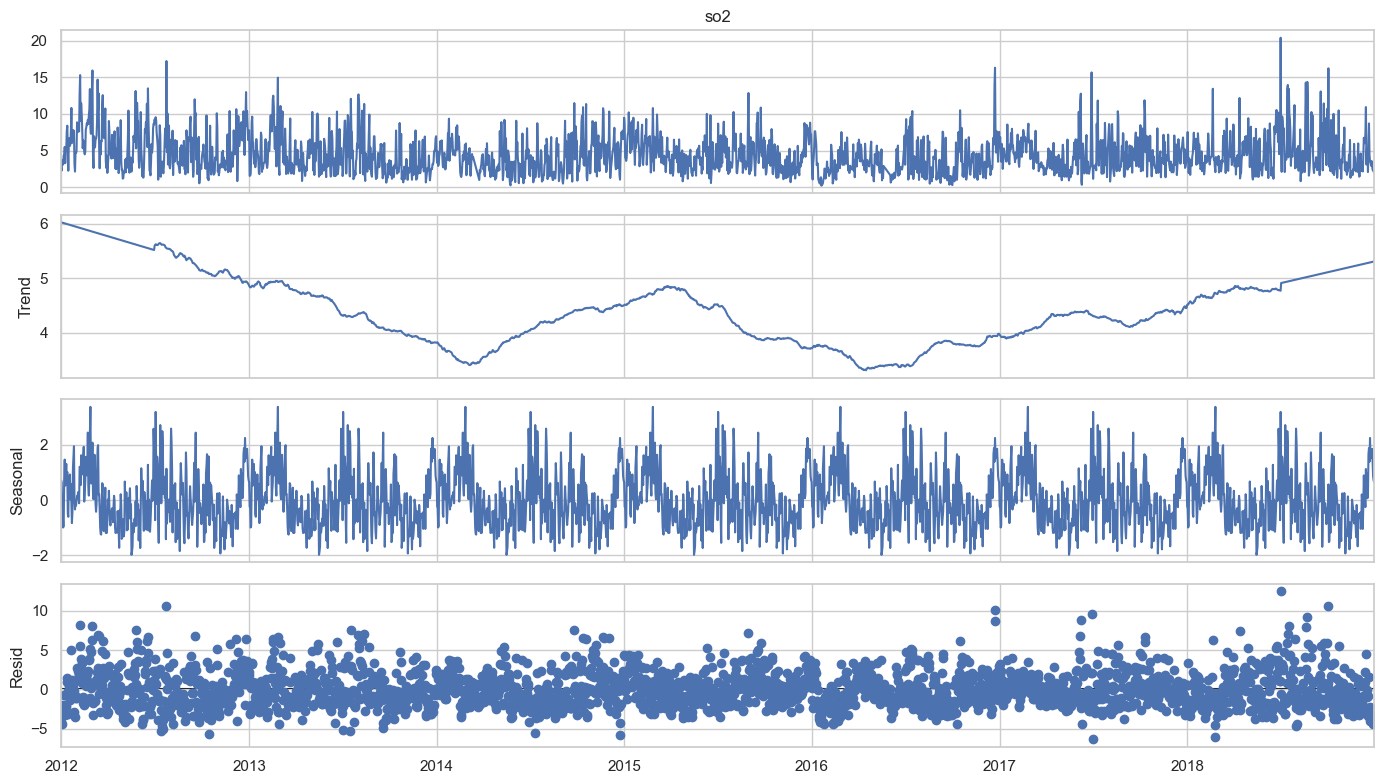

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,so2,1.287,9.334,127,5.012,127,5.012,20.389


Top 10 picos criticos:

,data,so2
2374,2018-07-02,20.389
205,2012-07-24,17.214
1818,2016-12-23,16.299
2467,2018-10-03,16.224
61,2012-03-02,15.929
2006,2017-06-29,15.663
37,2012-02-07,15.297
422,2013-02-26,14.946
71,2012-03-12,14.686
2426,2018-08-23,14.366


In [31]:
executar_eda_temporal_variavel("so2")


## 5.6 Variavel `co` (poluente)


### 1. Sazonalidade por mes, dia da semana e ano

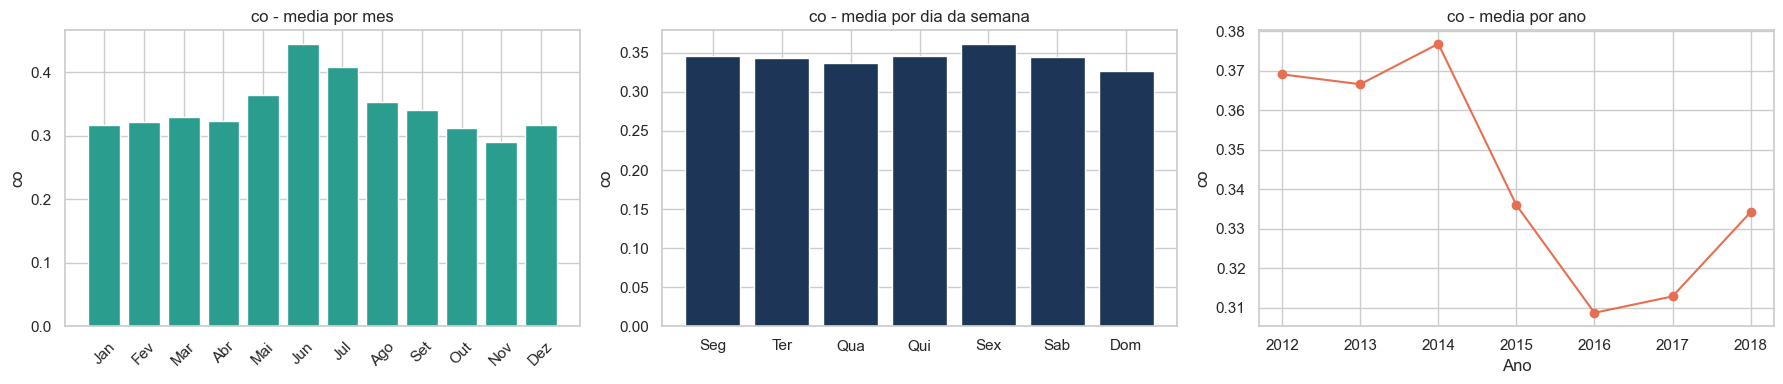

### 2. Tendencia de longo prazo (decomposicao temporal)

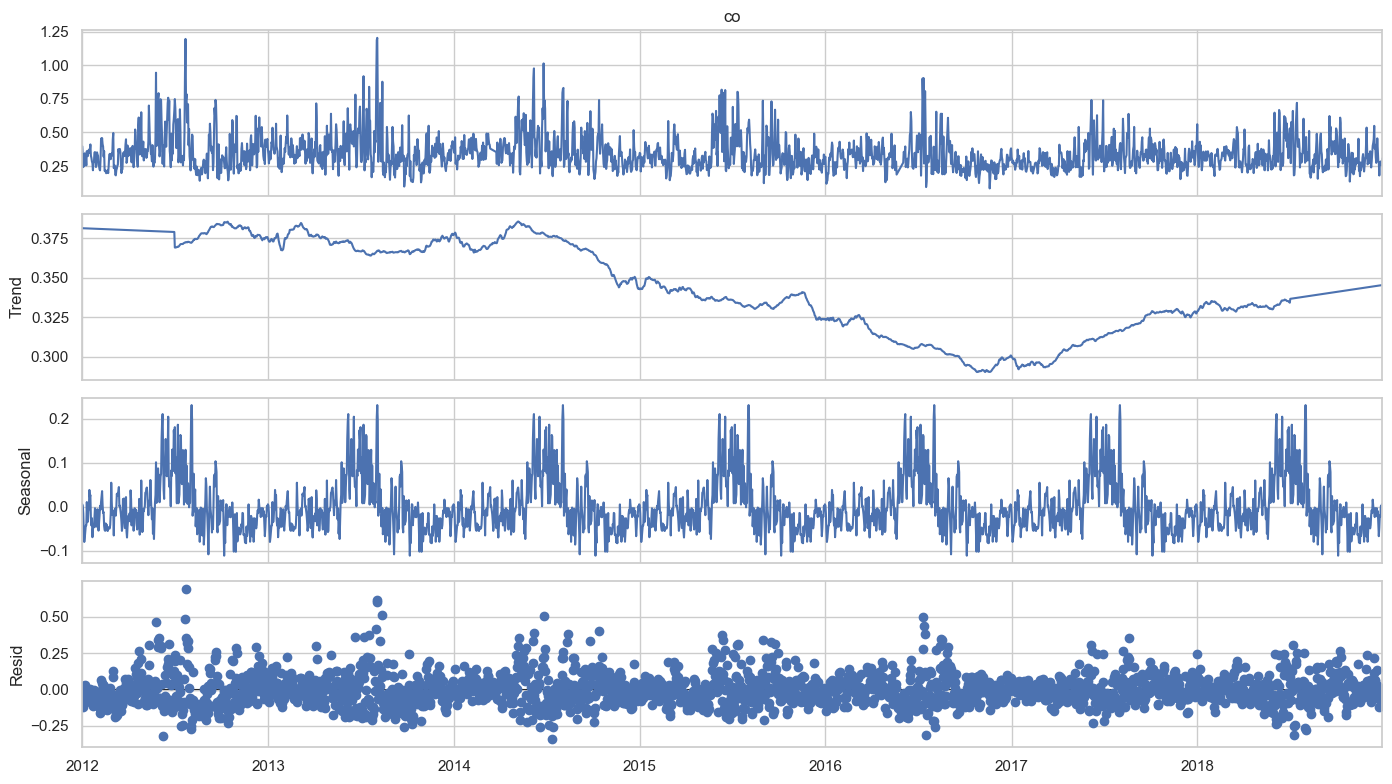

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,co,0.193,0.59,128,5.051,128,5.051,1.203


Top 10 picos criticos:

,data,co
580,2013-08-03,1.203
203,2012-07-22,1.195
579,2013-08-02,1.186
907,2014-06-26,1.013
888,2014-06-07,0.976
145,2012-05-25,0.944
202,2012-07-21,0.942
553,2013-07-07,0.918
887,2014-06-06,0.905
1654,2016-07-12,0.904


In [32]:
executar_eda_temporal_variavel("co")


## 5.7 Variavel `no` (poluente)


### 1. Sazonalidade por mes, dia da semana e ano

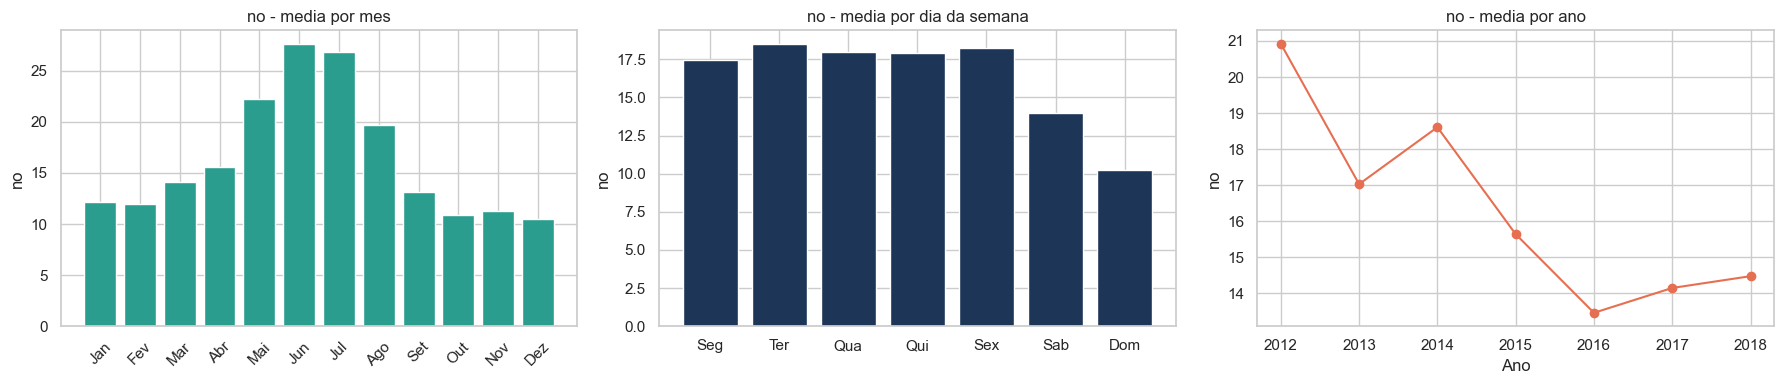

### 2. Tendencia de longo prazo (decomposicao temporal)

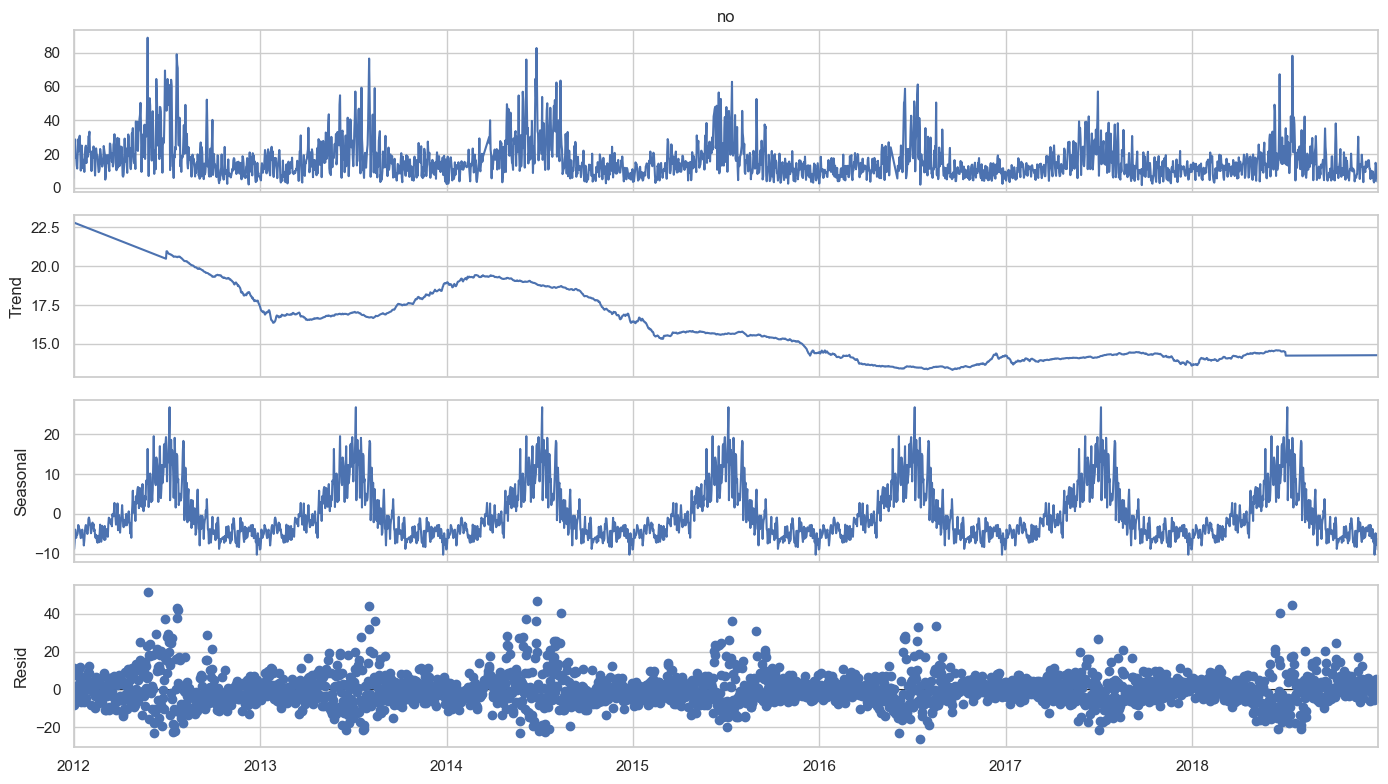

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,no,4.825,38.64,127,5.012,128,5.051,88.887


Top 10 picos criticos:

,data,no
145,2012-05-25,88.887
907,2014-06-26,82.762
202,2012-07-21,79.047
2388,2018-07-16,78.185
579,2013-08-02,76.543
887,2014-06-06,75.963
203,2012-07-22,72.865
204,2012-07-23,70.910
179,2012-06-28,69.449
2363,2018-06-21,67.249


In [33]:
executar_eda_temporal_variavel("no")


## 5.8 Variavel `nox` (poluente)


### 1. Sazonalidade por mes, dia da semana e ano

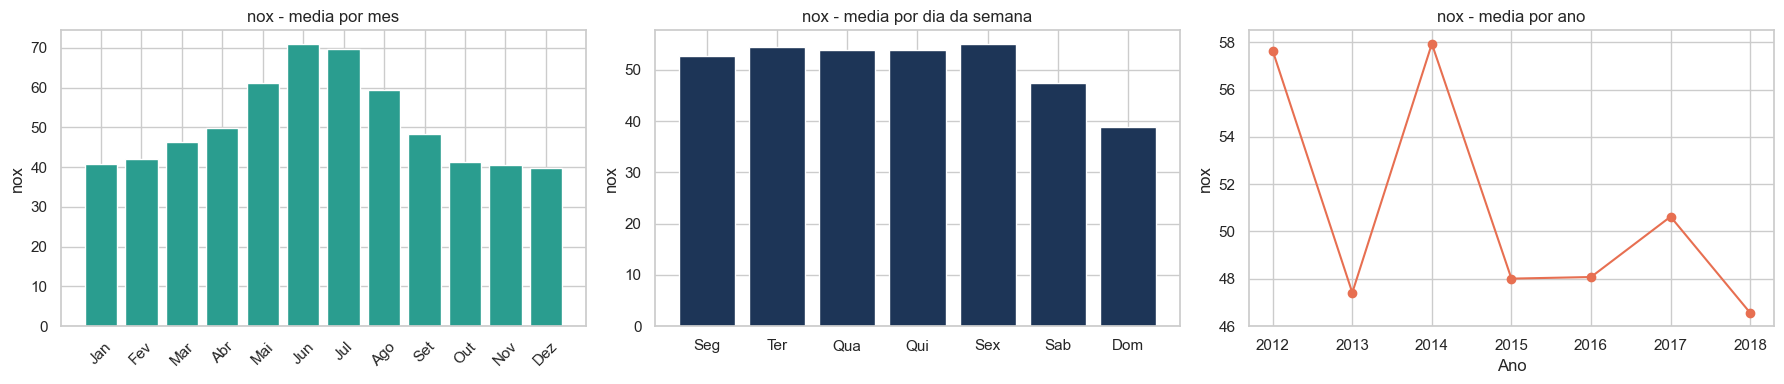

### 2. Tendencia de longo prazo (decomposicao temporal)

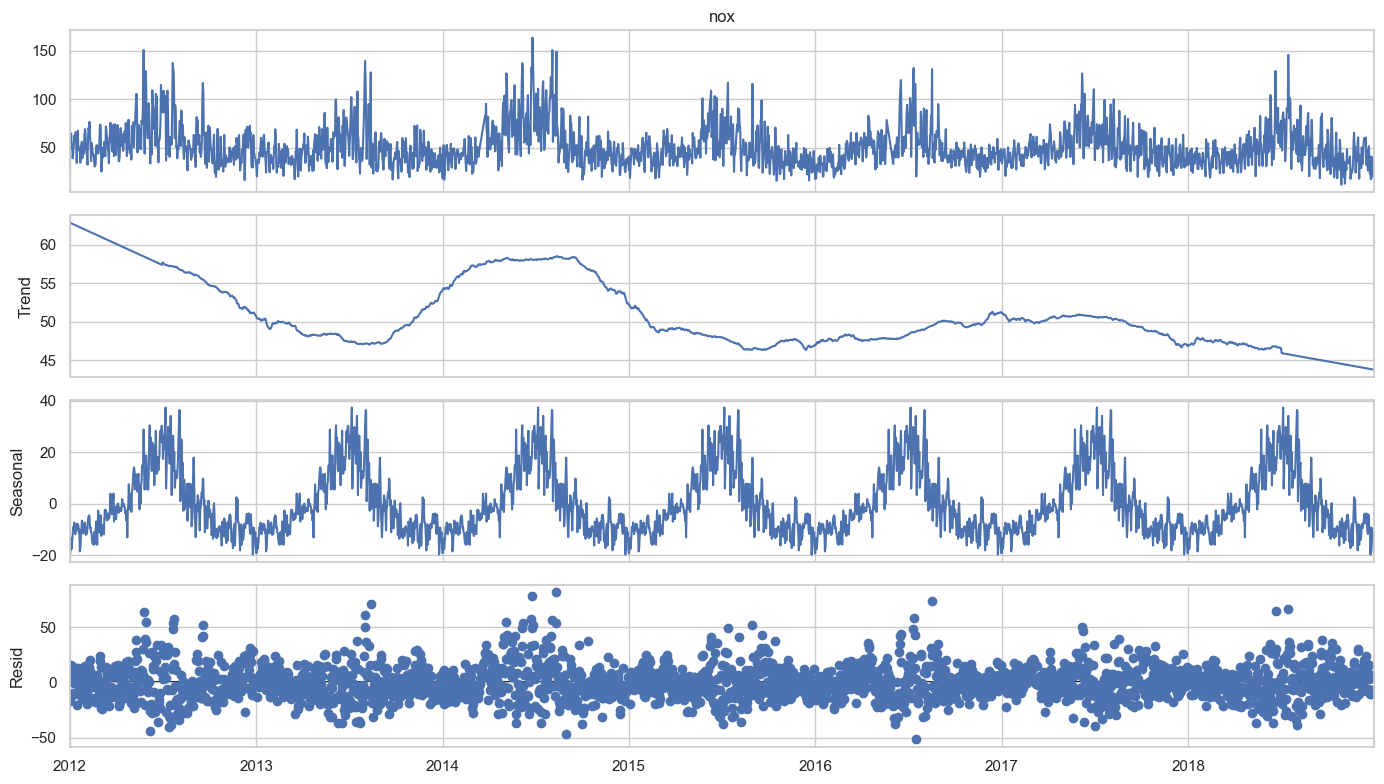

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,nox,26.174,91.368,127,5.012,127,5.012,163.708


Top 10 picos criticos:

,data,nox
907,2014-06-26,163.708
145,2012-05-25,150.909
946,2014-08-04,150.823
954,2014-08-12,149.457
2388,2018-07-16,145.945
579,2013-08-02,139.717
908,2014-06-27,138.593
202,2012-07-21,137.568
887,2014-06-06,137.386
905,2014-06-24,132.998


In [34]:
executar_eda_temporal_variavel("nox")


## 5.9 Variavel `temp` (atmosferica)


### 1. Sazonalidade por mes, dia da semana e ano

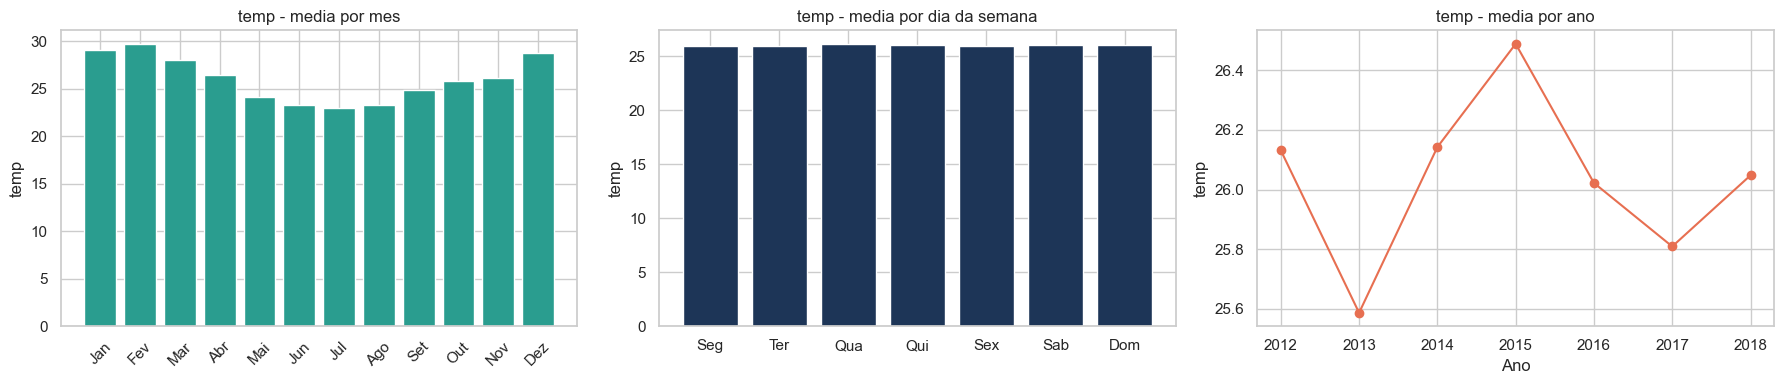

### 2. Tendencia de longo prazo (decomposicao temporal)

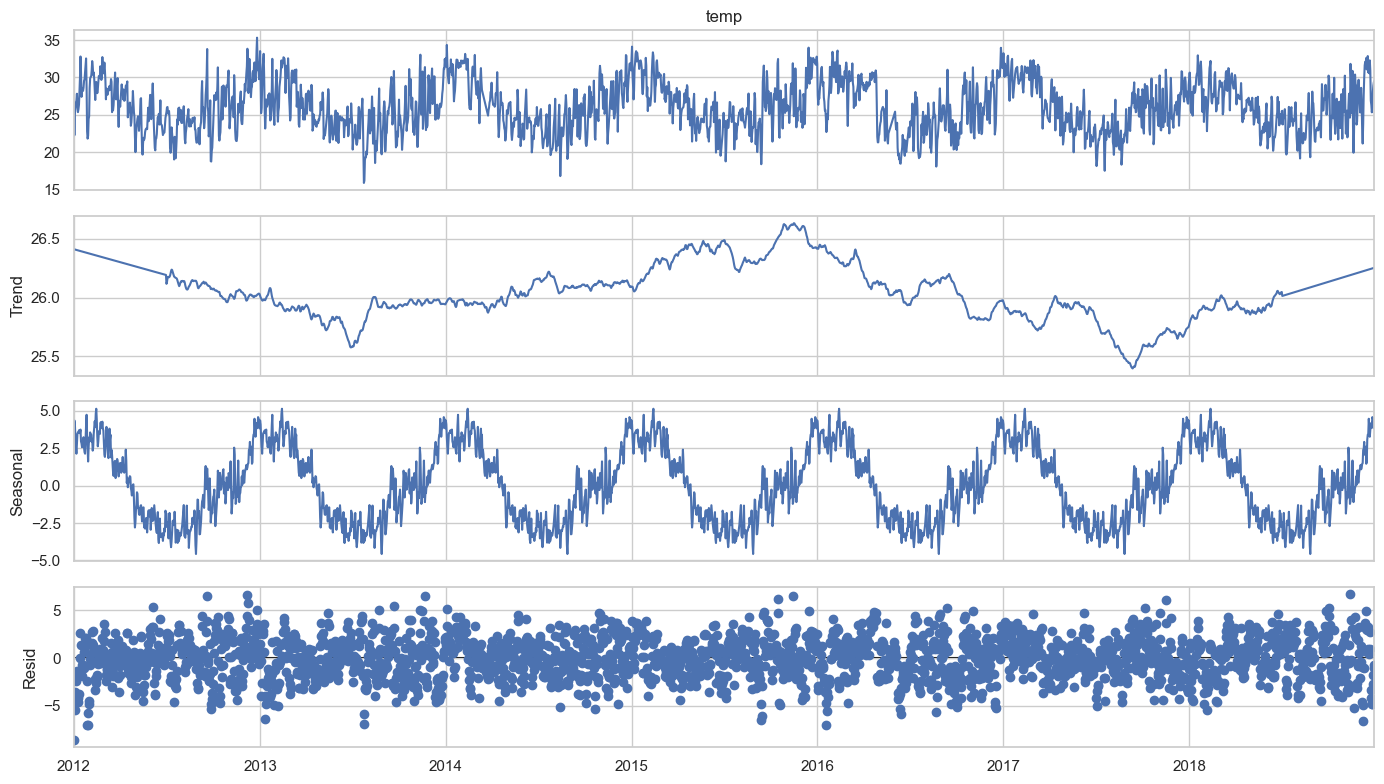

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,temp,20.86,31.579,127,5.012,127,5.012,35.313


Top 10 picos criticos:

,data,temp
360,2012-12-26,35.313
733,2014-01-03,34.341
1097,2015-01-02,34.116
1444,2015-12-15,33.981
1822,2016-12-27,33.958
341,2012-12-07,33.834
262,2012-09-19,33.797
1501,2016-02-10,33.586
366,2013-01-01,33.516
1105,2015-01-10,33.505


In [35]:
executar_eda_temporal_variavel("temp")


## 5.10 Variavel `ur` (atmosferica)


### 1. Sazonalidade por mes, dia da semana e ano

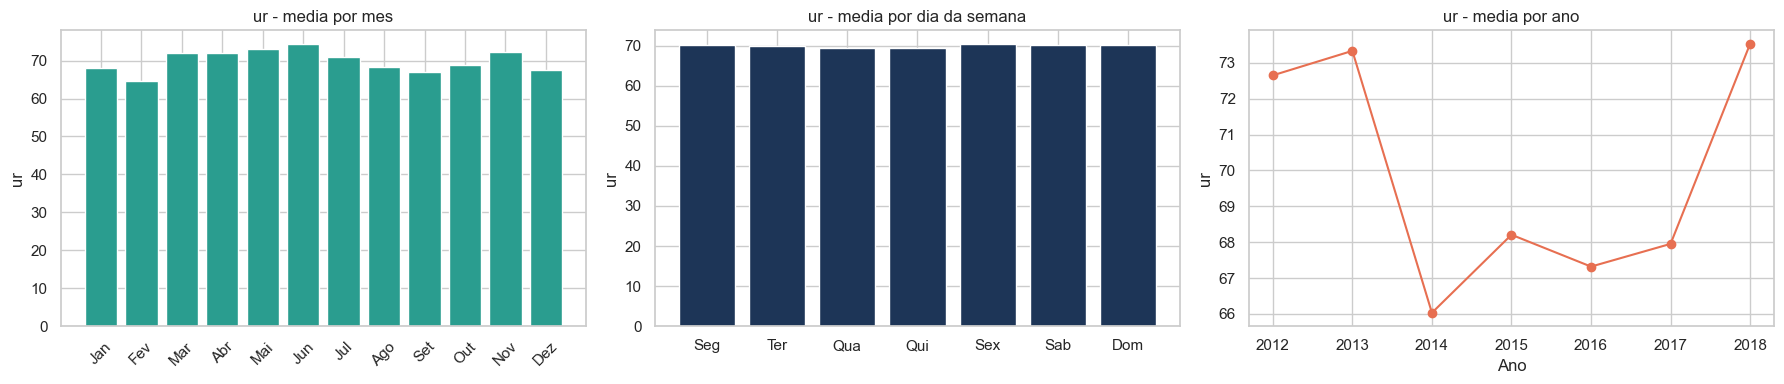

### 2. Tendencia de longo prazo (decomposicao temporal)

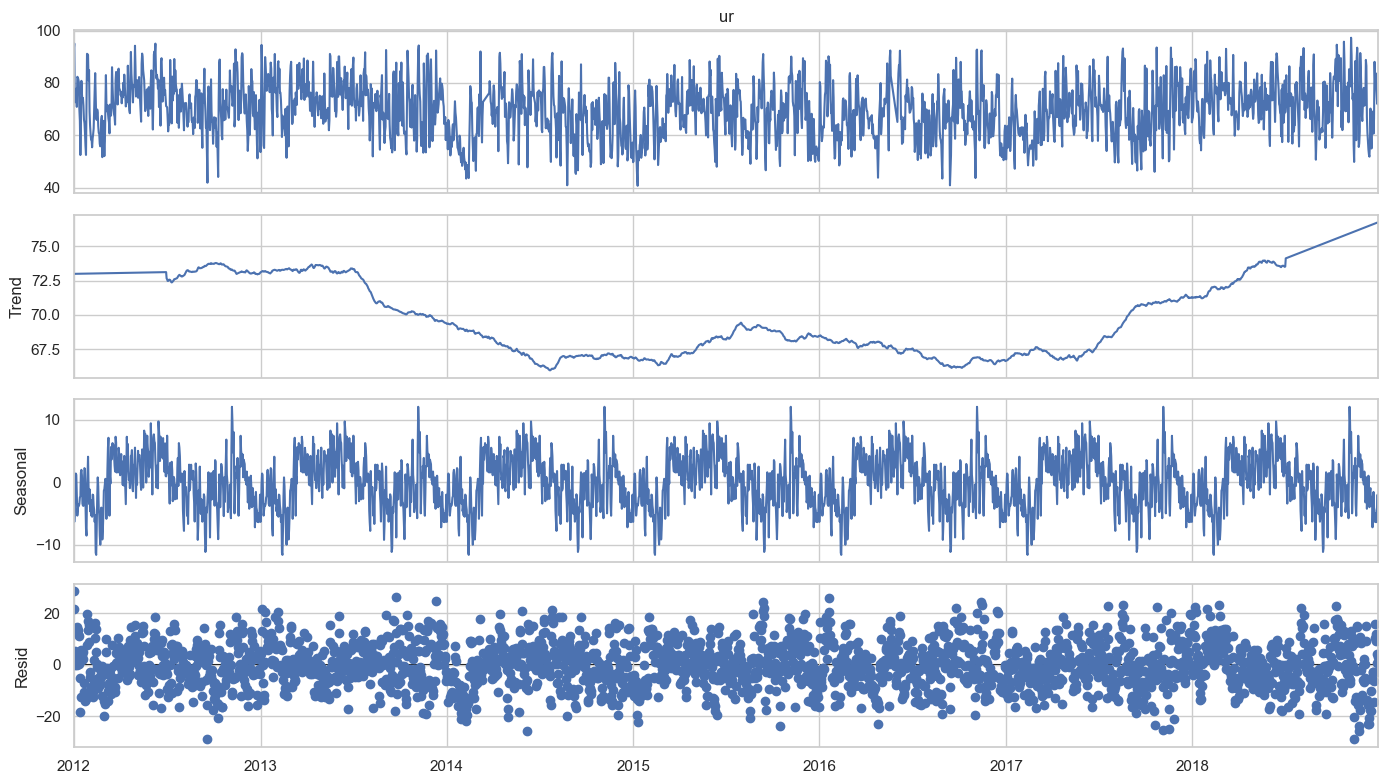

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,ur,52.596,87.584,127,5.012,127,5.012,97.247


Top 10 picos criticos:

,data,ur
2503,2018-11-08,97.247
2489,2018-10-25,95.734
1,2012-01-02,95.074
160,2012-06-09,95.002
2475,2018-10-11,94.581
368,2013-01-03,94.505
676,2013-11-07,94.293
120,2012-04-30,94.188
2122,2017-10-23,93.516
2150,2017-11-20,93.495


In [36]:
executar_eda_temporal_variavel("ur")


## 5.11 Variavel `chuva` (atmosferica)


### 1. Sazonalidade por mes, dia da semana e ano

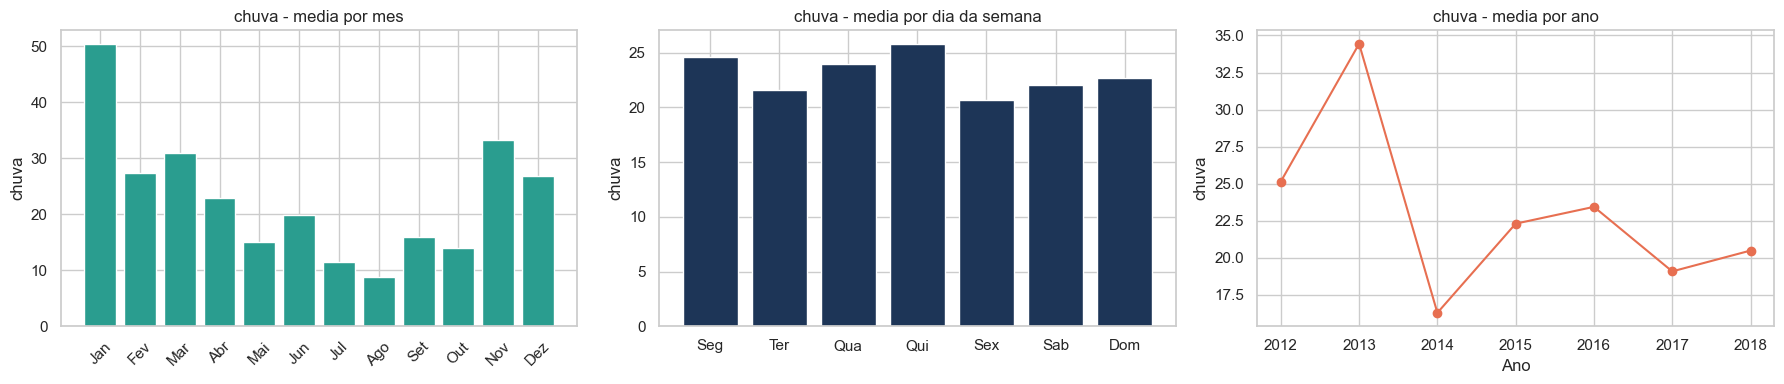

### 2. Tendencia de longo prazo (decomposicao temporal)

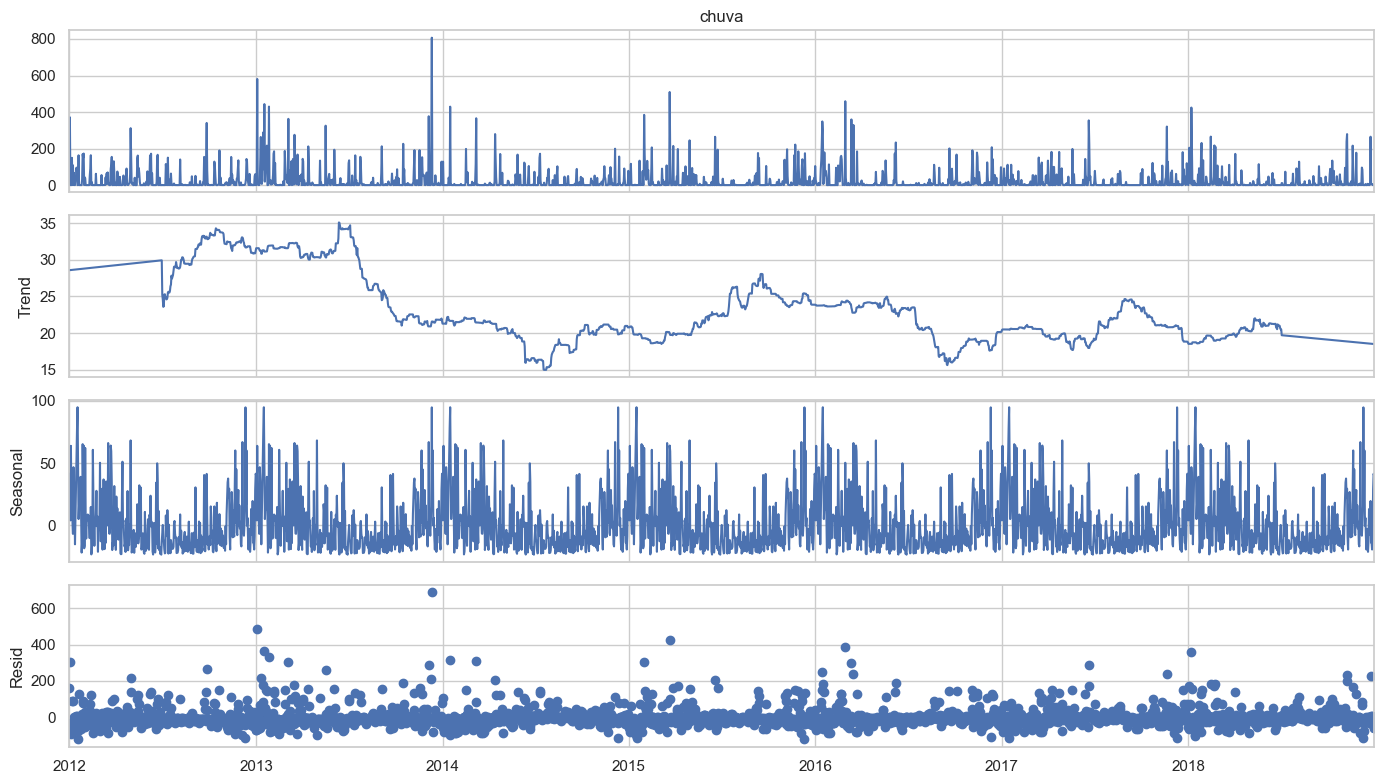

### 3. Dias/picos criticos e frequencia de eventos extremos

,variavel,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,maximo
0,chuva,0.0,140.36,128,5.006,1139,44.544,807.0


Top 10 picos criticos:

,data,chuva
710,2013-12-11,807.0
368,2013-01-03,581.0
1176,2015-03-22,509.6
1520,2016-02-29,459.0
382,2013-01-17,443.4
391,2013-01-26,429.8
746,2014-01-16,429.4
2198,2018-01-07,424.4
1126,2015-01-31,384.4
704,2013-12-05,376.8


In [37]:
executar_eda_temporal_variavel("chuva")


## 6. Tabela consolidada de extremos e tendencia


In [38]:
registros_consolidados = []

for variavel, resultado in resultados_temporais.items():
    resumo_extremos = resultado["extremos"]["resumo"].iloc[0]
    slope = resultado["tendencia"]["slope"]

    registros_consolidados.append(
        {
            "variavel": variavel,
            "grupo": resultado["grupo"],
            "p5": resumo_extremos["p5"],
            "p95": resumo_extremos["p95"],
            "qtd_extremos_altos": resumo_extremos["qtd_extremos_altos"],
            "freq_extremos_altos_pct": resumo_extremos["freq_extremos_altos_pct"],
            "qtd_extremos_baixos": resumo_extremos["qtd_extremos_baixos"],
            "freq_extremos_baixos_pct": resumo_extremos["freq_extremos_baixos_pct"],
            "slope_tendencia": slope,
            "metodo_tendencia": resultado["tendencia"]["origem"],
        }
    )

tabela_temporal_consolidada = pd.DataFrame(registros_consolidados)

if not tabela_temporal_consolidada.empty:
    tabela_temporal_consolidada = tabela_temporal_consolidada.sort_values(by=["grupo", "variavel"])
    colunas_round = [
        "p5",
        "p95",
        "freq_extremos_altos_pct",
        "freq_extremos_baixos_pct",
        "slope_tendencia",
    ]
    tabela_temporal_consolidada[colunas_round] = tabela_temporal_consolidada[colunas_round].round(3)

display(tabela_temporal_consolidada)


,variavel,grupo,p5,p95,qtd_extremos_altos,freq_extremos_altos_pct,qtd_extremos_baixos,freq_extremos_baixos_pct,slope_tendencia,metodo_tendencia
10,chuva,atmosferica,0.000,140.360,128,5.006,1139,44.544,-0.004,seasonal_decompose
8,temp,atmosferica,20.860,31.579,127,5.012,127,5.012,-0.000,seasonal_decompose
9,ur,atmosferica,52.596,87.584,127,5.012,127,5.012,-0.000,seasonal_decompose
5,co,poluente,0.193,0.590,128,5.051,128,5.051,-0.000,seasonal_decompose
6,no,poluente,4.825,38.640,127,5.012,128,5.051,-0.003,seasonal_decompose
3,no2,poluente,19.358,55.344,127,5.012,127,5.012,-0.001,seasonal_decompose
7,nox,poluente,26.174,91.368,127,5.012,127,5.012,-0.004,seasonal_decompose
2,o3,poluente,14.336,50.386,127,5.012,127,5.012,0.001,seasonal_decompose
0,pm10,poluente,19.171,63.317,127,5.012,127,5.012,-0.002,seasonal_decompose
1,pm2_5,poluente,6.325,38.005,126,5.008,126,5.008,-0.001,seasonal_decompose
